In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
os.environ['PYTHONPATH'] = ':'.join(sys.path)

In [2]:
import numpy as np
import awkward as ak
import hgpflow_v2.performance # don't know why this is needed, but it is
from hgpflow_v2.performance.performance import PerformanceATLAS
from hgpflow_v2.performance.reader import load_truth_atlas
from copy import deepcopy

/storage/agrp/dreyet/FullEventReco/HGPflow_ATLAS/hgpflow_v2/performance/performance.py:7: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy.optimize import linear_sum_assignment


### Thresholds

In [3]:
IND_THRESHOLD = 0.50
ASSOC_TRACK_PT_THRESHOLD = 100

In [4]:
save_dir = '/storage/agrp/dreyet/FullEventReco/HGPflow_ATLAS/plots_run4'
SAVE_FIG = True
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
FIGS = 'plot'

In [53]:
style_sheet = {
    'LABELS': {
        ### algorithms
        'truth': 'Truth',
        'ppflow': 'PPflow',
        'pandora': 'Pandora',
        'topo': 'TopoJet',
        'proxy': 'Proxy (track-sub)',
        'pflow': 'Proxy + Tracks',
        'hybrid': 'Proxy (calo-only)',
        'final': 'HGPflow Hybrid',
        'mpflow': 'GLOW',
        'hgpflow': 'HGPflow',
        'hgpflow_mini': 'HGPflow mini',
        'hgpflow_target': 'HGPflow target',
        'mlpf': 'MLPF',
        'empflow': 'EMPFlow',
        'emtopo': 'EMTopo',
        'lctopo': 'LCTopo',
        ### particles
        0: 'ch. had', 
        1: '$e^\pm$', 
        2: '$\mu^\pm$', 
        3: 'nu. had', 
        4: '$\gamma$', 
        5: 'resid.',
    },

    'LABEL_LEN': {
        'truth': 11,
        'proxy': 11,
        'pflow': 11,
        'hybrid': 10,
        'final': 10,
        'mpflow': 10,
        'topo' : 11,
        'ppflow': 10,
        'hgpflow': 8,
        'hgpflow_target': 8,
        'empflow': 10,
        'emtopo': 9,
    },

    'LINE_STYLES': {
        'truth': '--',
        'topo' : '-',
        'ppflow': '-',
        'proxy': '--',
        'hybrid': '--',
        'final': '-',
        'mpflow': '-',
        'pflow': '--',
        'hgpflow': '-',
        'hgpflow_target': '-',
        'empflow': '-',
        'emtopo': '--'
    },

    'MARKERS': {
        'truth': 'x',
        'topo': 'o',
        'ppflow': 'o',
        'proxy': 'x',
        'pflow': 'x',
        'hybrid': 'x',
        'final': '^',
        'hgpflow': 'o',
        'hgpflow_target': 'x',
        'mpflow': '^',
        'empflow': 'h',
        'emtopo': 's'
    },

    'COLORS': {
        'truth': 'black',
        'topo': 'greenyellow',
        'ppflow': 'gray',
        'proxy': 'blue',
        'pflow': 'purple',
        'hybrid': 'purple',
        'final': 'firebrick',
        'hgpflow': 'firebrick',
        'mpflow': 'darkorange',
        'hgpflow_target': 'darkorange',
        'empflow': 'teal',
        'emtopo': 'olivedrab'
    },

    'HISTTYPES': {
        'truth': 'step',
        'ppflow': 'bar',
        'pandora': 'bar',
        'topo': 'bar',
        'proxy': 'step',
        'pflow': 'step',
        'hybrid': 'step',
        'final': 'step',
        'mpflow': 'step',
        'hgpflow': 'step',
        'hgpflow_mini': 'step',
        'hgpflow_target': 'step',
        'mlpf': 'step',
        'empflow': 'bar',
        'emtopo': 'bar',
        'lctopo': 'bar',
    },

    'ALPHAS': {
        'truth': 1.0,
        'ppflow': 0.5,
        'pandora': 0.5,
        'topo': 0.5,
        'proxy': 1.0,
        'hybrid': 1.0,
        'final': 1.0,
        'mpflow': 1.0,
        'pflow': 1.0,
        'hgpflow': 1.0,
        'hgpflow_mini': 1.0,
        'hgpflow_target': 1.0,
        'mlpf': 1.0,
        'empflow': 0.5,
        'emtopo': 0.5,
        'lctopo': 0.5,
    }
}

# Dijet

In [6]:
truth_path = "" #'/storage/agrp/dreyet/FullEventReco/HGPflow_ATLAS/event_segmentation/pbs_scripts/atlas_test_truth_May2026.txt'
truth_cache_path = '/storage/agrp/dreyet/FullEventReco/HGPflow_ATLAS/event_segmentation/pbs_scripts/atlas_test_truth_May2026_topo0_fid0.parquet'
truth_jets_path = '/storage/agrp/dreyet/Run4MLTreeAthenaAnalysis/samples/noPU/user.edreyer.80116*.Py8EG_A14NNPDF23LO_jj_JZ*.recon.AOD.e8481_s4383_r17563_j12_mltree.root/merged_JZ*_jets.root'
pred_paths = {
    # 'hgpflow': ''
    'mpflow': '/storage/agrp/dreyet/GLOW/hepattn_nilotpal/experiments/atlas_run4_jz1234_v1_20260603-T173408/ckpts/epoch=027-val_loss=5.33018__test.root',
}

In [7]:
truth_dict = load_truth_atlas(truth_path, topo=False, fiducial_cuts=False, 
                              cache_path=truth_cache_path, jets_path=truth_jets_path)

Loading truth from cache: /storage/agrp/dreyet/FullEventReco/HGPflow_ATLAS/event_segmentation/pbs_scripts/atlas_test_truth_May2026_topo0_fid0.parquet
Loading jets from 4 file(s) with 32 workers...


In [8]:
# JZ 123
# event_numbers_jz123 = np.arange(7500 * 3)

perf_obj = PerformanceATLAS(
    truth_path=truth_dict,
    pred_paths=pred_paths, 
    ind_threshold=IND_THRESHOLD, 
    topo=False, proxy=True, target_path=None, load_hung_matched_truth=False,
    fiducial_cuts_on_truth=False,
    # event_numbers=event_numbers_jz123,
    load_truth=True,
    entry_stop=None,
    num_workers=32)

Loading mpflow predictions: 190497/190497 events, 32 workers, step_size=50000


Loading mpflow predictions...: 100%|██████████| 4/4 [00:32<00:00,  8.15s/it]


  read done in 71.3s
  load_predictions total: 214.2s
common event count: 169497


Filtering and reordering mpflow predictions...: 100%|██████████| 19/19 [00:00<00:00, 694.33it/s]


In [ ]:
perf_obj.compute_jets(n_procs=30)

Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
AntiKt4TruthJets
AntiKt4EMPFlowJets
AntiKt4EMTopoJets
mpflow
Jet clustering algorithm:  antikt

Jet clustering radius:  0.4Processed 0/6349 events...
Jet clustering algorithm: 0.4 antikt
Jet clustering radius:  
Processed 0/6350 events...
Jet clustering algorithm:  antikt#--------------------------------------------------------------------------
#                         FastJet release 3.4.0
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without w

Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
Processed 0/6349 events...
Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
Processed 0/6350 events...
Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
Processed 0/6350 events...
Jet clustering algorithm: 
 antikt
Jet clustering radius:  0.4Processed 0/6350 events...
Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
Processed 0/6350 events...
Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
Processed 0/6350 events...
Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
Processed 0/6350 events...
Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
Processed 0/6350 events...
Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
Processed 0/6350 events...
Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
Processed 0/6350 events...
Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
Processed 0/6349 events...
Jet clustering algori

In [10]:
perf_obj.match_jets()

Matching jets...: 100%|██████████| 190497/190497 [00:24<00:00, 7791.76it/s]


In [11]:
def get_track_substituted_perf(is_charged_mask, ptetaphi, trackptetaphi, tag=None, track_pt_threshold=ASSOC_TRACK_PT_THRESHOLD):
    out_dict = {}

    if tag is not None:
        tag = f'{tag}_'

    # eta-phi for all charged particles
    out_dict[tag + 'eta'] = ak.where(
        is_charged_mask, 
        trackptetaphi['eta'], 
        ptetaphi['eta'])

    out_dict[tag + 'phi'] = ak.where(
        is_charged_mask, 
        trackptetaphi['phi'], 
        ptetaphi['phi'])

    # pt only below certain track pT. Above threshold, use default pt (can be from mpflow or calo proxy)
    assoc_track_pt_mask = trackptetaphi['pt'] < track_pt_threshold
    ch_pt_mask = is_charged_mask * assoc_track_pt_mask

    out_dict[tag + 'pt'] = ak.where(
        ch_pt_mask, 
        trackptetaphi['pt'], 
        ptetaphi['pt'])
    
    return out_dict

In [12]:
if 'hgpflow' in pred_paths:
    hgpflow_class = perf_obj.pred_dicts['hgpflow']['hgpflow_class']
    hgpflow_is_charged = hgpflow_class <= 2
    hgpflow_ptetaphi = {
        'pt': perf_obj.pred_dicts['hgpflow']['hgpflow_pt'],
        'eta': perf_obj.pred_dicts['hgpflow']['hgpflow_eta'],
        'phi': perf_obj.pred_dicts['hgpflow']['hgpflow_phi']
    }
    proxy_ptetaphi = {
        'pt': perf_obj.pred_dicts['hgpflow']['proxy_pt'],
        'eta': perf_obj.pred_dicts['hgpflow']['proxy_eta'],
        'phi': perf_obj.pred_dicts['hgpflow']['proxy_phi']
    }
    track_ptetaphi = {
        'pt': perf_obj.pred_dicts['hgpflow']['assoc_track_pt'],
        'eta': perf_obj.pred_dicts['hgpflow']['assoc_track_eta'],
        'phi': perf_obj.pred_dicts['hgpflow']['assoc_track_phi']
    }
    hgpflow_track_sub_dict = get_track_substituted_perf(hgpflow_is_charged,
                                                        hgpflow_ptetaphi, 
                                                        track_ptetaphi, 
                                                        tag='hgpflow_tracksub',
                                                        track_pt_threshold=ASSOC_TRACK_PT_THRESHOLD)
    
    hgpflow_proxy_track_sub_dict = get_track_substituted_perf(hgpflow_is_charged,
                                                        proxy_ptetaphi, 
                                                        track_ptetaphi, 
                                                        tag='hgpflow_proxy_tracksub',
                                                        track_pt_threshold=ASSOC_TRACK_PT_THRESHOLD)

    perf_obj.pred_dicts['hgpflow'].update({k: v for k, v in hgpflow_track_sub_dict.items()})
    perf_obj.pred_dicts['hgpflow'].update({k: v for k, v in hgpflow_proxy_track_sub_dict.items()})

if 'mpflow' in pred_paths:

    mpflow_proxy_is_charged = perf_obj.pred_dicts['mpflow']['proxy_is_charged']

    track_ptetaphi = {
        'pt': perf_obj.pred_dicts['mpflow']['proxy_ch_pt'],
        'eta': perf_obj.pred_dicts['mpflow']['proxy_ch_eta'],
        'phi': perf_obj.pred_dicts['mpflow']['proxy_ch_phi']
    }

    proxy_ptetaphi = {
        'pt': perf_obj.pred_dicts['mpflow']['proxy_pt'],
        'eta': perf_obj.pred_dicts['mpflow']['proxy_eta'],
        'phi': perf_obj.pred_dicts['mpflow']['proxy_phi']
    }

    mpflow_ptetaphi = {
        'pt': perf_obj.pred_dicts['mpflow']['mpflow_pt'],
        'eta': perf_obj.pred_dicts['mpflow']['mpflow_eta'],
        'phi': perf_obj.pred_dicts['mpflow']['mpflow_phi']
    }

    mpflow_track_sub_dict = get_track_substituted_perf(mpflow_proxy_is_charged,
                                                        mpflow_ptetaphi, 
                                                        track_ptetaphi,
                                                        tag='mpflow_tracksub',
                                                        track_pt_threshold=ASSOC_TRACK_PT_THRESHOLD)
    
    mpflow_proxy_track_sub_dict = get_track_substituted_perf(mpflow_proxy_is_charged,
                                                        proxy_ptetaphi, 
                                                        track_ptetaphi,
                                                        tag='mpflow_proxy_tracksub',
                                                        track_pt_threshold=ASSOC_TRACK_PT_THRESHOLD)

    ### Additional collection: mpflow_track_sub but with raw calo proxy substituted for charged particles above track pT threshold
    ### (i.e. substitute tracks for low-pT charged particles, substitute raw calo for high-pT charged particles)
    hybrid_ptetaphi = {
        'pt': ak.where(mpflow_proxy_is_charged,  
                       perf_obj.pred_dicts['mpflow']['proxy_neut_pt'], 
                       perf_obj.pred_dicts['mpflow']['mpflow_pt']),
        'eta': perf_obj.pred_dicts['mpflow']['mpflow_eta'],
        'phi': perf_obj.pred_dicts['mpflow']['mpflow_phi']
    }
    mpflow_hybrid_track_sub_dict = get_track_substituted_perf(mpflow_proxy_is_charged,
                                                        hybrid_ptetaphi, 
                                                        track_ptetaphi,
                                                        tag='mpflow_tracksub_calosub',
                                                        track_pt_threshold=ASSOC_TRACK_PT_THRESHOLD)
    
    perf_obj.pred_dicts['mpflow'].update({k: v for k, v in mpflow_track_sub_dict.items()})
    perf_obj.pred_dicts['mpflow'].update({k: v for k, v in mpflow_proxy_track_sub_dict.items()})
    perf_obj.pred_dicts['mpflow'].update({k: v for k, v in mpflow_hybrid_track_sub_dict.items()})


In [13]:
from hgpflow_v2.performance.jet_helper import JetHelper, compute_jets
jet_obj = JetHelper(radius=0.4, algo='antikt')

model_name = 'mpflow'
pred_dict = perf_obj.pred_dicts[model_name]

for key in ['tracksub', 'proxy_tracksub', 'tracksub_calosub']:
    actual_key = f'{model_name}_{key}'
    print(f'{model_name} {key}')
    pred_dict[key + '_jets'] = compute_jets(jet_obj,
        pred_dict[f'{actual_key}_pt'], pred_dict[f'{actual_key}_eta'],
        pred_dict[f'{actual_key}_phi'], pred_dict[f'{model_name}_mass'],
        fourth_name='mass', n_procs=30)

Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
mpflow tracksub
mpflow proxy_tracksub
mpflow tracksub_calosub


In [14]:
### Calo proxy mpflow jets
pred_dict['mpflow_calo_jets'] = compute_jets(jet_obj,
    pred_dict['proxy_neut_pt'],
    ak.where(pred_dict['proxy_is_charged'], pred_dict['proxy_ch_eta'], pred_dict['proxy_neut_eta']),
    ak.where(pred_dict['proxy_is_charged'], pred_dict['proxy_ch_phi'], pred_dict['proxy_neut_phi']),
    pred_dict['mpflow_mass'],
    fourth_name='mass', n_procs=30)

In [15]:
### match additional collections

model_name = 'mpflow'
pred_dict = perf_obj.pred_dicts[model_name]
for key in ['tracksub', 'proxy_tracksub', 'tracksub_calosub', 'mpflow_calo']:
    print(f'{model_name} {key}')
    pred_dict[f'matched_{key}_jets'] = perf_obj.match_jets_all_ev(
        perf_obj.truth_dict['AntiKt4TruthJets'],
        pred_dict[key + '_jets']
    )

mpflow tracksub


Matching jets...: 100%|██████████| 190497/190497 [00:26<00:00, 7322.40it/s]


mpflow proxy_tracksub


Matching jets...: 100%|██████████| 190497/190497 [00:24<00:00, 7712.25it/s]


mpflow tracksub_calosub


Matching jets...: 100%|██████████| 190497/190497 [00:29<00:00, 6498.41it/s]


mpflow mpflow_calo


Matching jets...: 100%|██████████| 190497/190497 [00:21<00:00, 8726.46it/s]


### Jet residual plots

In [16]:
def find_matching_jet(jets, target_jet, delta_r_threshold=0.1):
    '''
    Find the jet in 'jets' that matches the target_eta and target_phi within delta_r_threshold.
    Returns the index of the matching jet, or -1 if no match is found.
    '''
    delta_rs = []
    for idx, jet in enumerate(jets):
        delta_r = jet.delta_R(target_jet)
        delta_rs.append((delta_r, idx))
    delta_rs.sort(key=lambda x: x[0])  # Sort by delta_r
    if delta_rs and delta_rs[0][0] < delta_r_threshold:
        return delta_rs[0][1]
    else:
        return -1

def decaying_coeff(y, y_threshold, decay_ratio=0.5):
    decay_rate = decay_ratio * y_threshold
    erf = lambda x: (1 + np.tanh(x / decay_rate)) / 2
    alpha = erf(y_threshold - y)
    return alpha


from copy import deepcopy
def best_of_both_jets(low_pt_matched_jets, high_pt_matched_jets, comp_jet_pt_threshold=250, delta_r_threshold=0.1, pt_consistency_threshold=None):
    '''
    Combine two sets of matched jets, taking jets from the low_pt set if their pt is below a threshold,
    and from the high_pt set if their pt is above the threshold.
    '''
    low_ref_jets, low_comp_jets = low_pt_matched_jets
    high_ref_jets, high_comp_jets = high_pt_matched_jets
    best_ref_jets, best_comp_jets = [], []
    for ev in range(len(low_ref_jets)):
        ref_jets_ev = []
        comp_jets_ev = []
        for low_ref_jet, low_comp_jet in zip(low_ref_jets[ev], low_comp_jets[ev]):
            substitute_comp_jet = None
            if (low_comp_jet.pt - comp_jet_pt_threshold)/comp_jet_pt_threshold > -0.5:
                ### look for matching comp jet in high pt jets
                match_idx = find_matching_jet(high_comp_jets[ev], low_comp_jet, delta_r_threshold=delta_r_threshold)
                if match_idx >= 0:
                    
                    substitute_comp_jet = deepcopy(high_comp_jets[ev][match_idx])

                    if pt_consistency_threshold is not None:
                        ### Final check: pt consistency near threshold
                        if (low_comp_jet.pt - comp_jet_pt_threshold)/comp_jet_pt_threshold < pt_consistency_threshold:
                            relative_pt_diff = np.abs(substitute_comp_jet.pt - low_comp_jet.pt) / low_comp_jet.pt
                            if relative_pt_diff > pt_consistency_threshold:
                                substitute_comp_jet = None


            if substitute_comp_jet is None:
                comp_jets_ev.append(low_comp_jet)
            else:
                ### Smooth average
                alpha = decaying_coeff(low_comp_jet.pt, y_threshold=comp_jet_pt_threshold)
                substitute_comp_jet.pt = alpha * low_comp_jet.pt + (1 - alpha) * substitute_comp_jet.pt
                comp_jets_ev.append(substitute_comp_jet)

            ### will not "cheat" -- need to keep ref jet the same
            ref_jets_ev.append(low_ref_jet)

        best_ref_jets.append(ref_jets_ev)
        best_comp_jets.append(comp_jets_ev)
    return best_ref_jets, best_comp_jets

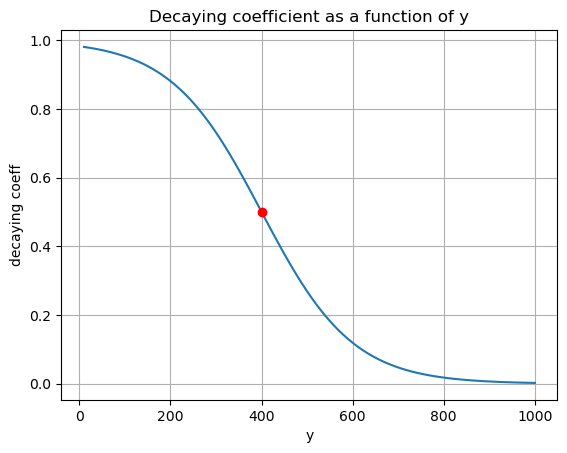

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
thresh = 400
y = np.linspace(10, 1000, 100)

ax.plot(y, decaying_coeff(y, y_threshold=thresh))
ax.plot([thresh], [decaying_coeff(thresh, y_threshold=thresh)], 'ro')
ax.set_xlabel('y')
ax.set_ylabel('decaying coeff')
ax.set_title('Decaying coefficient as a function of y')
plt.grid()

In [18]:
if 'hgpflow' in pred_paths:
    hybrid_hgpflow_proxy_jets = best_of_both_jets(
        perf_obj.pred_dicts['hgpflow']['matched_proxy_tracksub_jets'],
        perf_obj.pred_dicts['hgpflow']['matched_proxy_jets'],
        comp_jet_pt_threshold=400,
        delta_r_threshold=0.4,
        # pt_consistency_threshold=0.2
    )

    hybrid_hgpflow_jets = best_of_both_jets(
        perf_obj.pred_dicts['hgpflow']['matched_tracksub_jets'],
        perf_obj.pred_dicts['hgpflow']['matched_proxy_jets'],
        comp_jet_pt_threshold=400,
        delta_r_threshold=0.4,
        # pt_consistency_threshold=0.1
    )

if 'mpflow' in pred_paths:
    hybrid_mpflow_proxy_jets = best_of_both_jets(
        perf_obj.pred_dicts['mpflow']['matched_proxy_tracksub_jets'],
        perf_obj.pred_dicts['mpflow']['matched_mpflow_calo_jets'],
        comp_jet_pt_threshold=400,
        delta_r_threshold=0.4,
        # pt_consistency_threshold=0.1
    )

    hybrid_mpflow_jets = best_of_both_jets(
        perf_obj.pred_dicts['mpflow']['matched_tracksub_jets'],
        perf_obj.pred_dicts['mpflow']['matched_mpflow_calo_jets'],
        comp_jet_pt_threshold=400,
        delta_r_threshold=0.4,
        # pt_consistency_threshold=0.1
    )


In [19]:
for k in perf_obj.pred_dicts['mpflow'].keys():
    if 'matched' in k:
        print(k)

matched_mpflow_jets
matched_proxy_jets
matched_tracksub_jets
matched_proxy_tracksub_jets
matched_tracksub_calosub_jets
matched_mpflow_calo_jets


In [49]:
from hgpflow_v2.performance.plot_helper_event import compute_jet_residual_dict

_dict = {
    'emtopo' : perf_obj.truth_dict['matched_AntiKt4EMTopoJets'],
    'empflow': perf_obj.truth_dict['matched_AntiKt4EMPFlowJets'],
    # 'proxy'  : perf_obj.pred_dicts['hgpflow']['matched_proxy_jets'],
    # 'proxy'  : perf_obj.pred_dicts['hgpflow']['matched_proxy_tracksub_jets'],
    # 'hybrid': hybrid_proxy_jets,
    # 'hgpflow': perf_obj.pred_dicts['hgpflow']['matched_hgpflow_jets'],
    # 'hgpflow': perf_obj.pred_dicts['hgpflow']['matched_tracksub_jets'],
    # 'final': hybrid_hgpflow_jets,
    # 'proxy'  : perf_obj.pred_dicts['mpflow']['matched_proxy_jets'],
    # 'mpflow': perf_obj.pred_dicts['mpflow']['matched_mpflow_jets'],
    'proxy': perf_obj.pred_dicts['mpflow']['matched_proxy_tracksub_jets'],
    # 'mpflow': perf_obj.pred_dicts['mpflow']['matched_tracksub_jets'], #tracksub_calosub_jets'],
    'hybrid': perf_obj.pred_dicts['mpflow']['matched_mpflow_calo_jets'],
    # 'hybrid': hybrid_mpflow_jets, #perf_obj.pred_dicts['mpflow']['matched_proxy_tracksub_jets'],
    # 'pflow'  : perf_obj.pred_dict['matched_pflow_jets'],
    # 'topo'   : perf_obj.truth_dict['matched_topo_jets'],
    # 'truth': perf_obj.truth_dict['matched_truth_jets'],
    # f'{model_name}_target': perf_obj.hgpflow_target_dict['matched_hgpflow_target_jets'],
}

jet_residual_dict = compute_jet_residual_dict(_dict, dr_cut=0.1, leading_N_jets=2, pt_min=20)

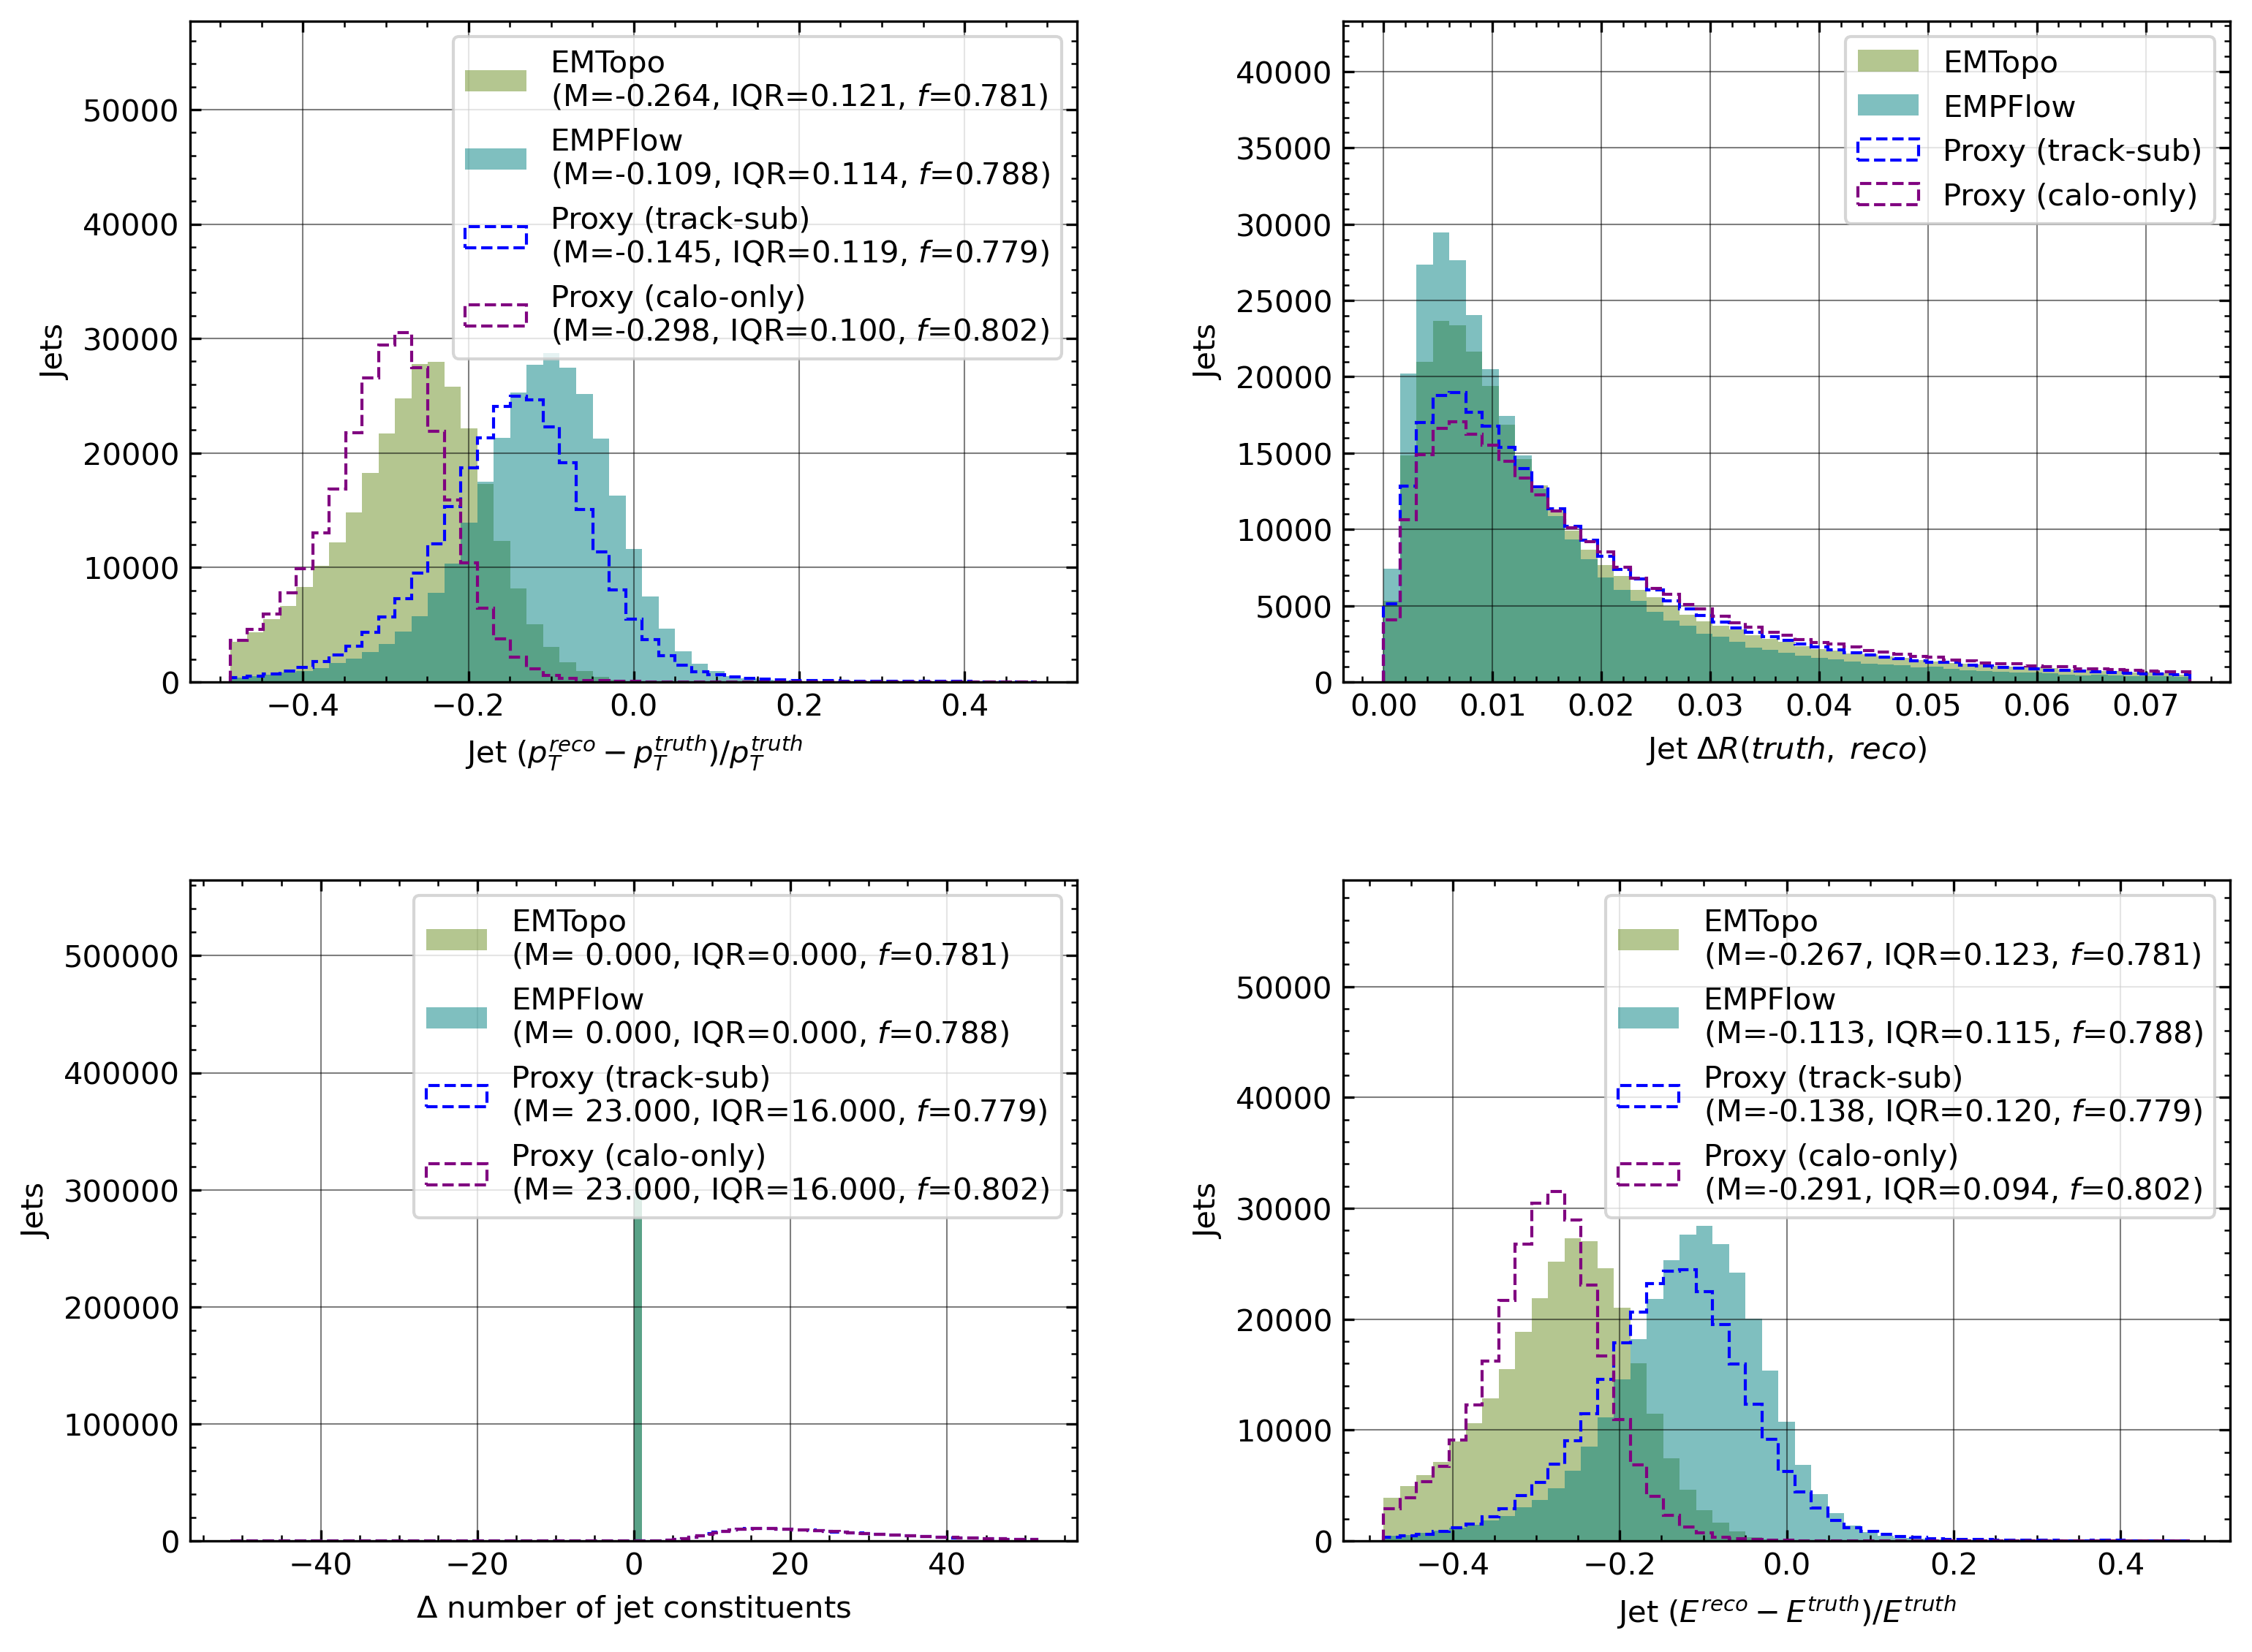

In [54]:
from hgpflow_v2.performance.plot_helper_event import plot_jet_residuals

figs = plot_jet_residuals(jet_residual_dict, pt_relative=True, stylesheet=style_sheet, separate_figures=False)
if SAVE_FIG:
    # figs[0].savefig(f'{save_dir}/dijet_jet_residuals_pt.png', dpi=300)
    # figs[1].savefig(f'{save_dir}/dijet_jet_residuals_dr.png', dpi=300)
    # figs[2].savefig(f'{save_dir}/dijet_jet_residuals_constcount.png', dpi=300)
    figs.savefig(f'{save_dir}/{FIGS}_dijet_jet_residuals.png', dpi=300)

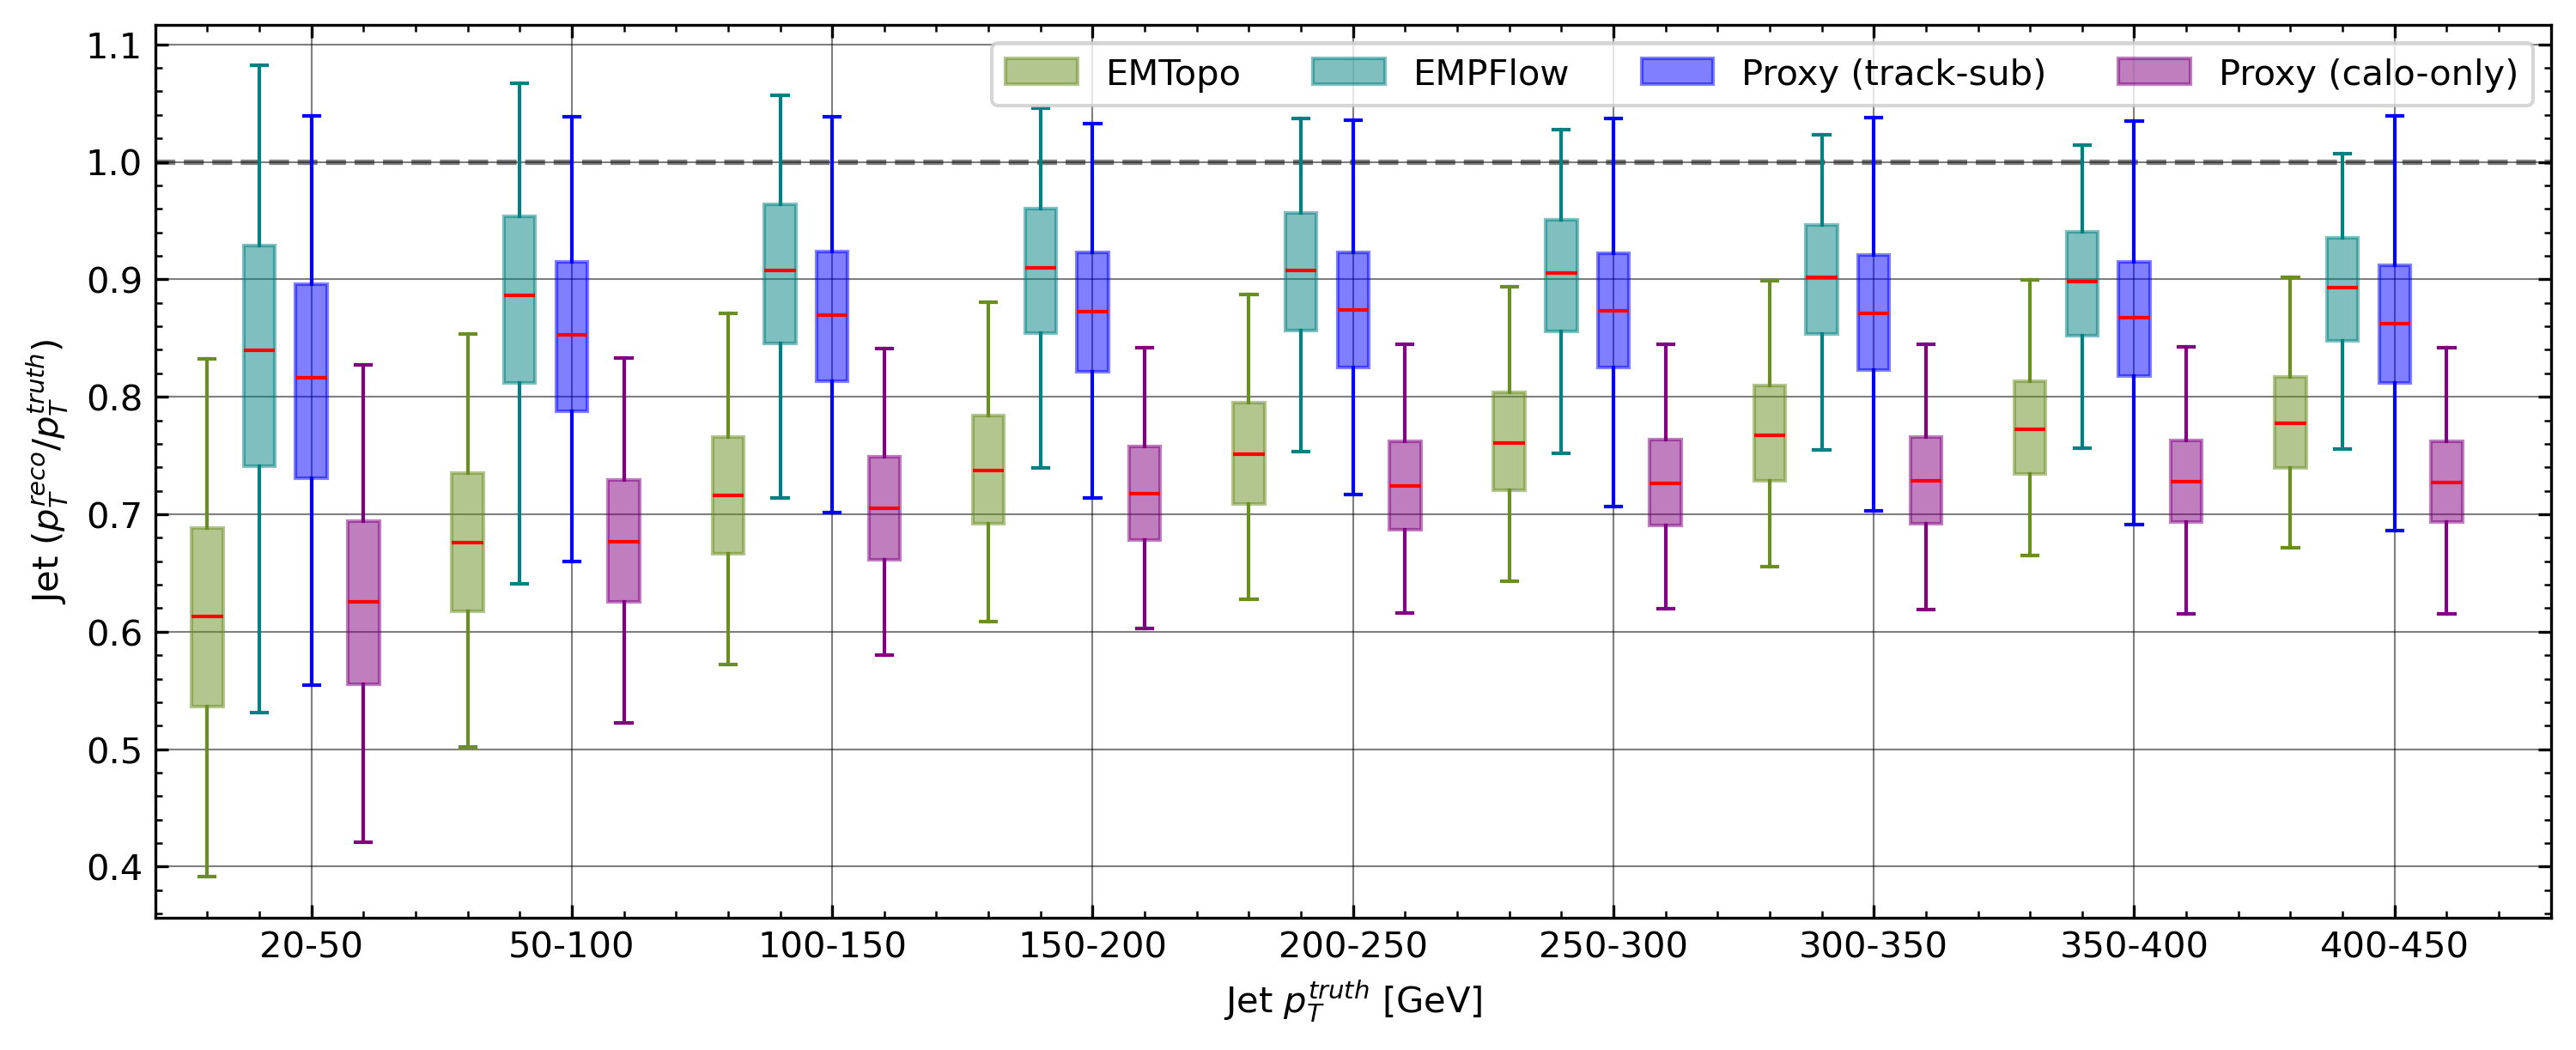

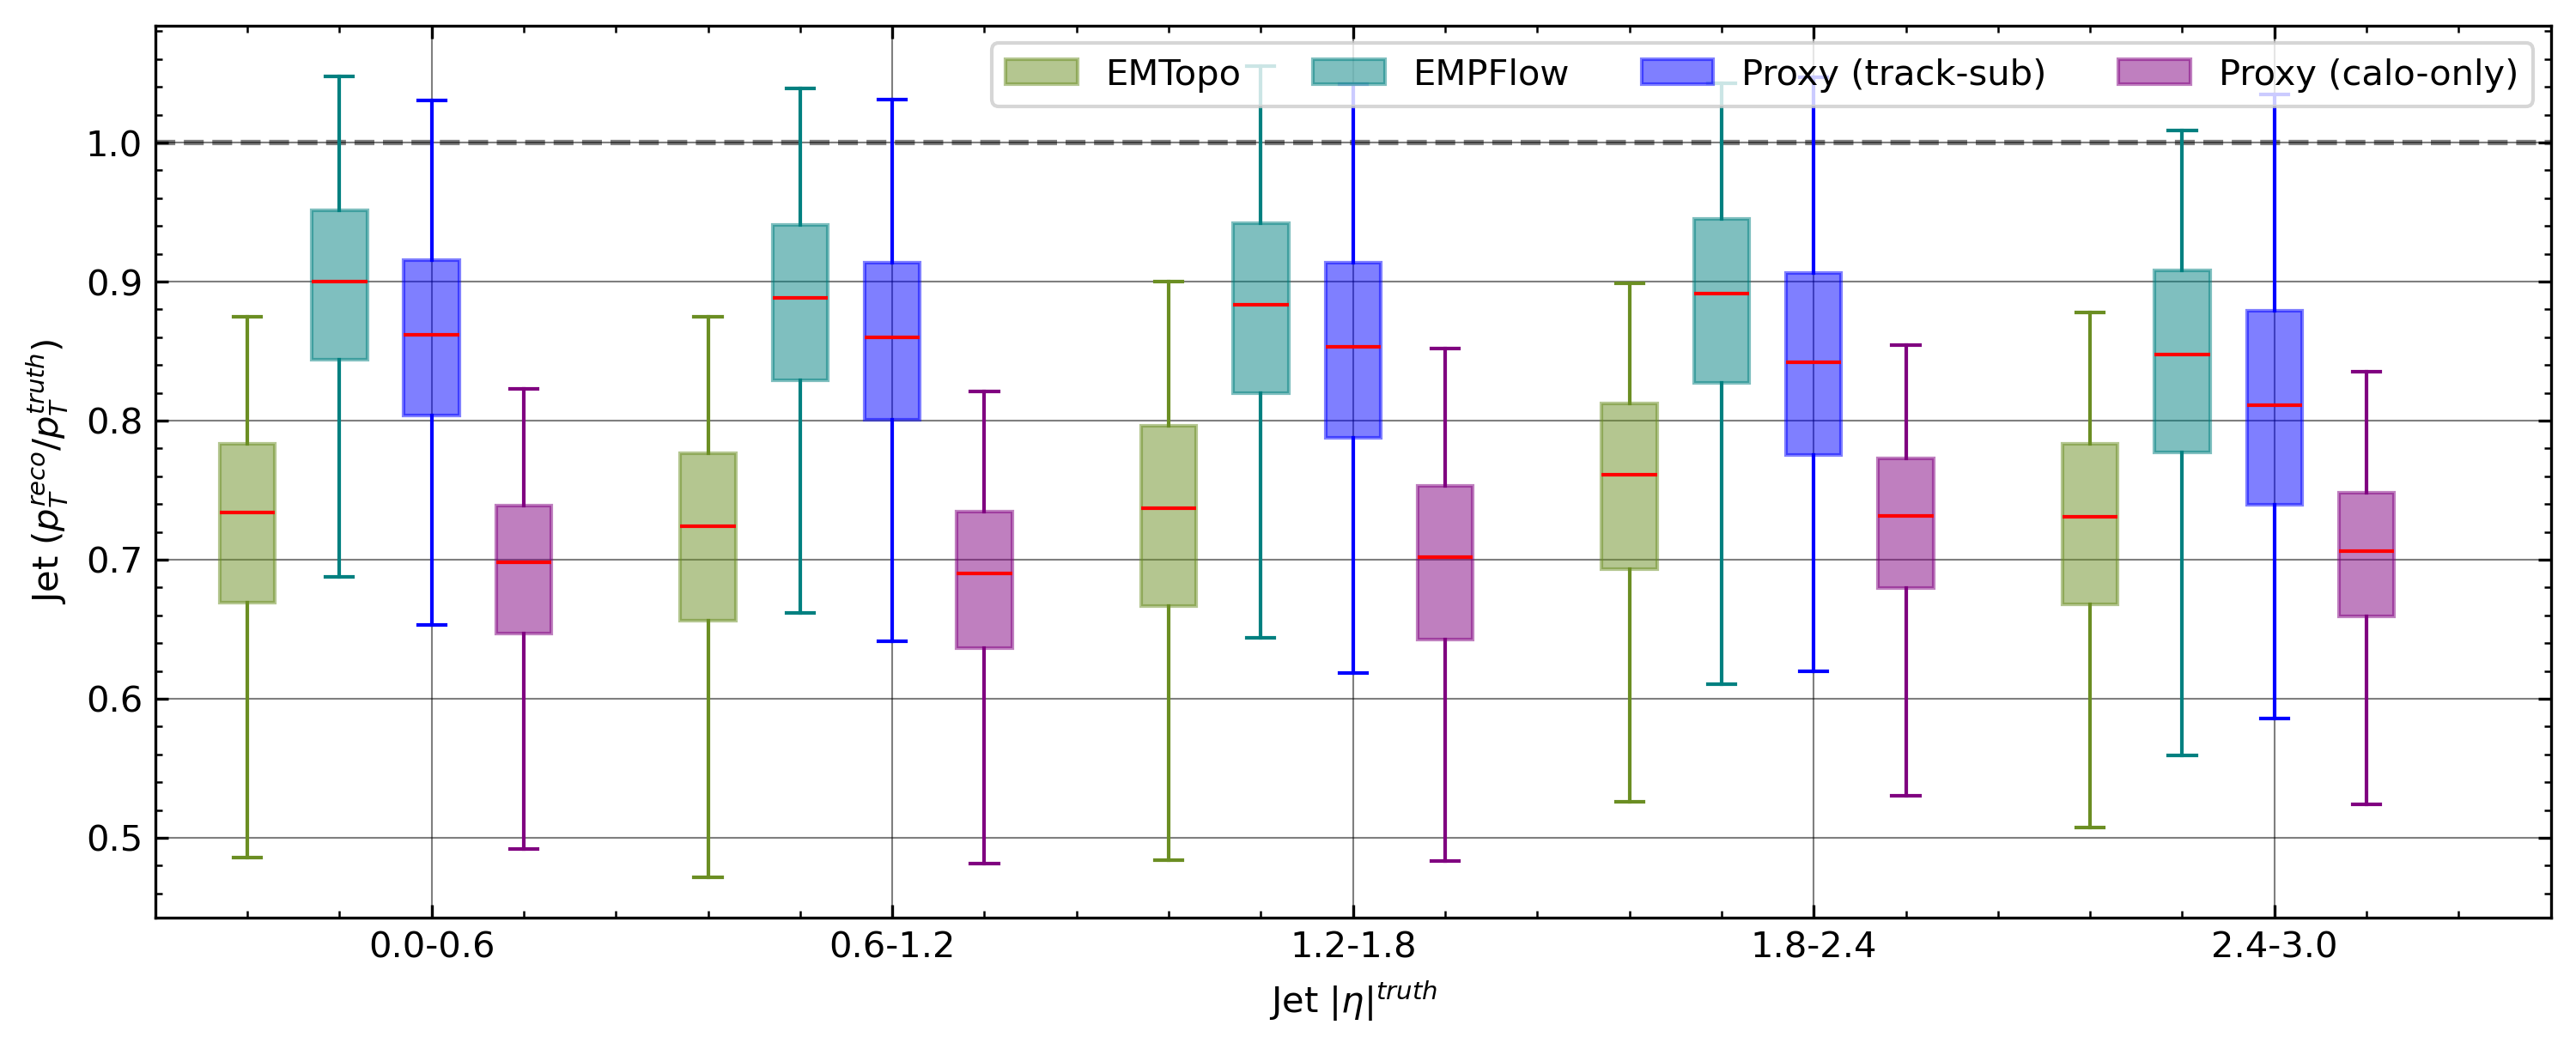

In [55]:
from hgpflow_v2.performance.plot_helper_event import plot_jet_ratio_boxplot

pt_bins = np.array([20, 50, 100, 150, 200, 250, 300, 350, 400, 450])
# pt_bins = np.array([20, 50, 100, 200, 300, 400, 600, 800, 1000])
# pt_bins = np.array([20, 50, 100, 200, 300, 400, 600, 800, 1000, 1500])

fig_pt = plot_jet_ratio_boxplot(jet_residual_dict, bins=pt_bins, stylesheet=style_sheet)

# eta_bins = np.linspace(-3, 3, 15)
abs_eta_bins = np.linspace(0, 3, 6)
fig_eta = plot_jet_ratio_boxplot(jet_residual_dict, var='abseta', bins=abs_eta_bins, stylesheet=style_sheet)

if SAVE_FIG:
    fig_pt.savefig(f'{save_dir}/{FIGS}_dijet_jet_ratio_pt_boxplot.png', dpi=300)
    fig_eta.savefig(f'{save_dir}/{FIGS}_dijet_jet_ratio_eta_boxplot.png', dpi=300)

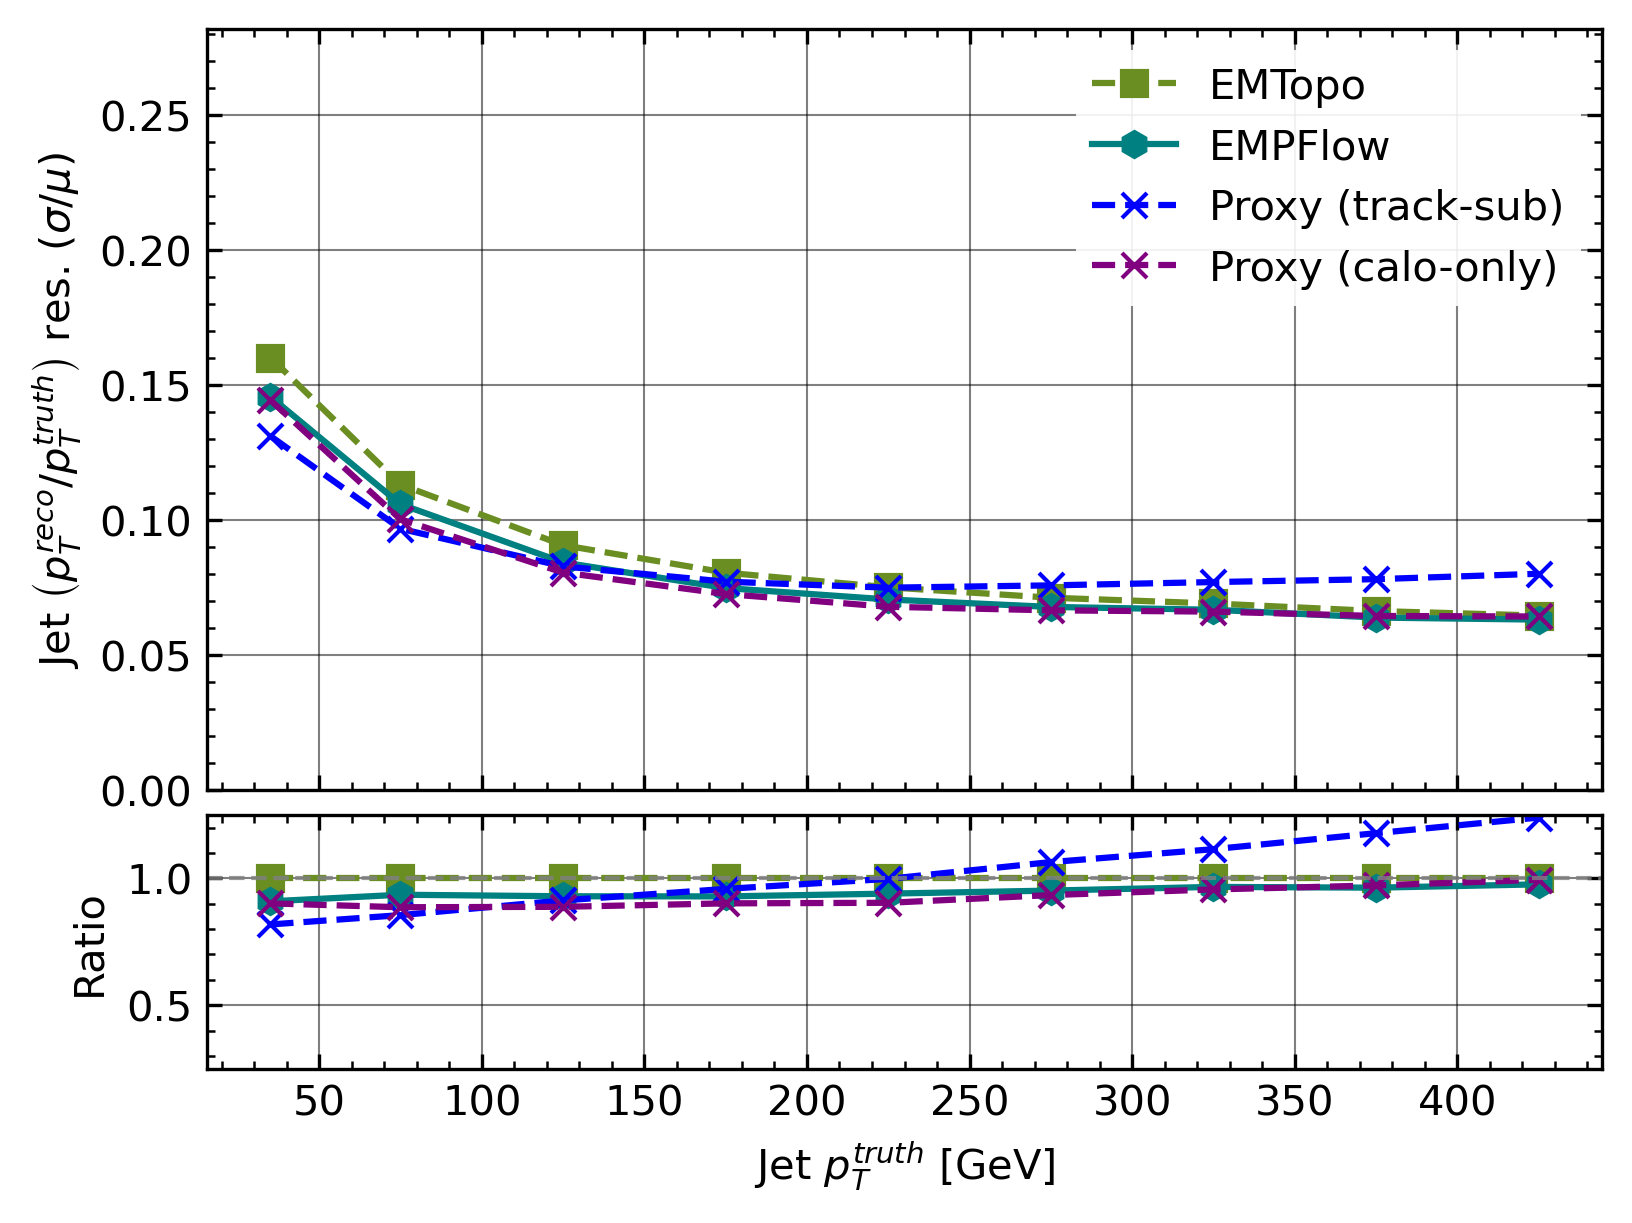

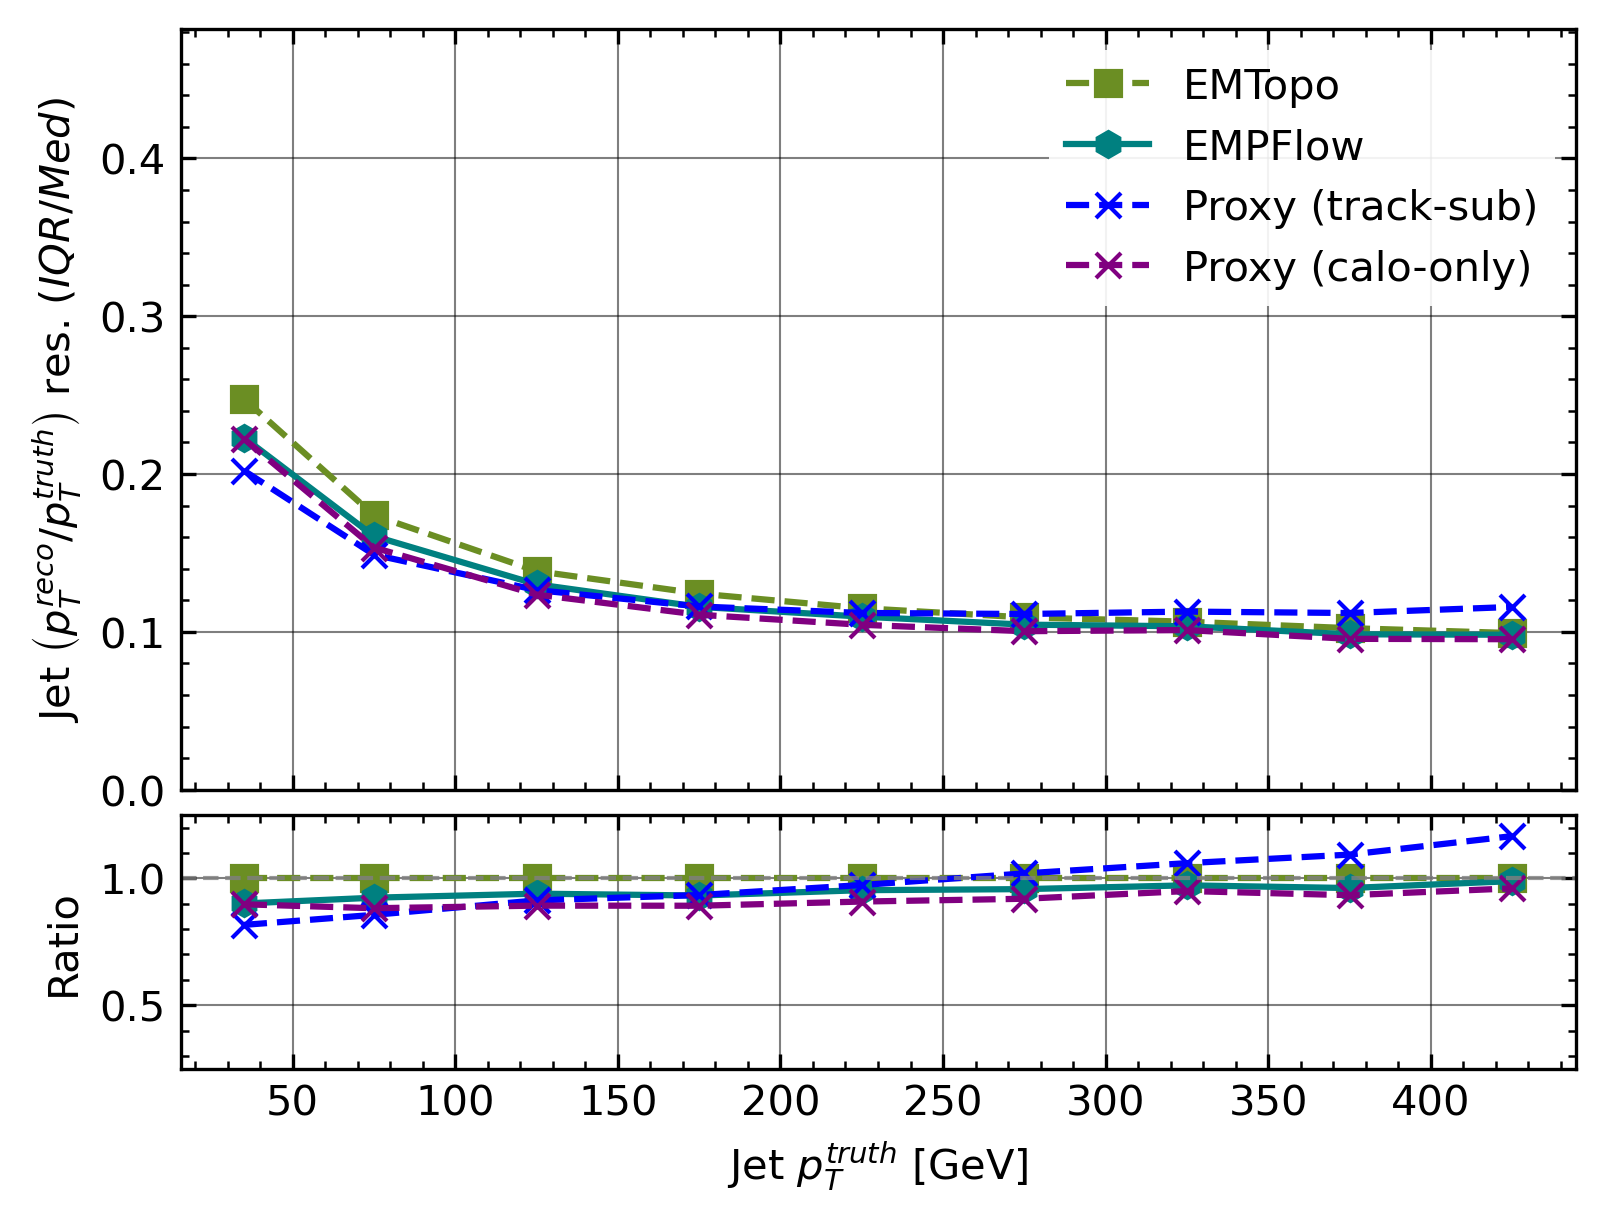

In [58]:
from hgpflow_v2.performance.plot_helper_event import plot_jet_response

pt_bins = np.array([20, 50, 100, 150, 200, 250, 300, 350, 400, 450])
# pt_bins = np.array([20, 50, 100, 200, 300, 400, 600, 800, 1000])
# pt_bins = np.array([20, 50, 100, 200, 300, 400, 600, 800, 1000, 1500])
figs = plot_jet_response(jet_residual_dict, pt_bins=pt_bins, separate_figures=True, stylesheet=style_sheet, ratio_panel=True)

if SAVE_FIG:
    figs[0].savefig(f'{save_dir}/{FIGS}_dijet_jet_response_meanstd.png', dpi=300)
    figs[1].savefig(f'{save_dir}/{FIGS}_dijet_jet_response_medianiqr.png', dpi=300)

#### Marginal distributions

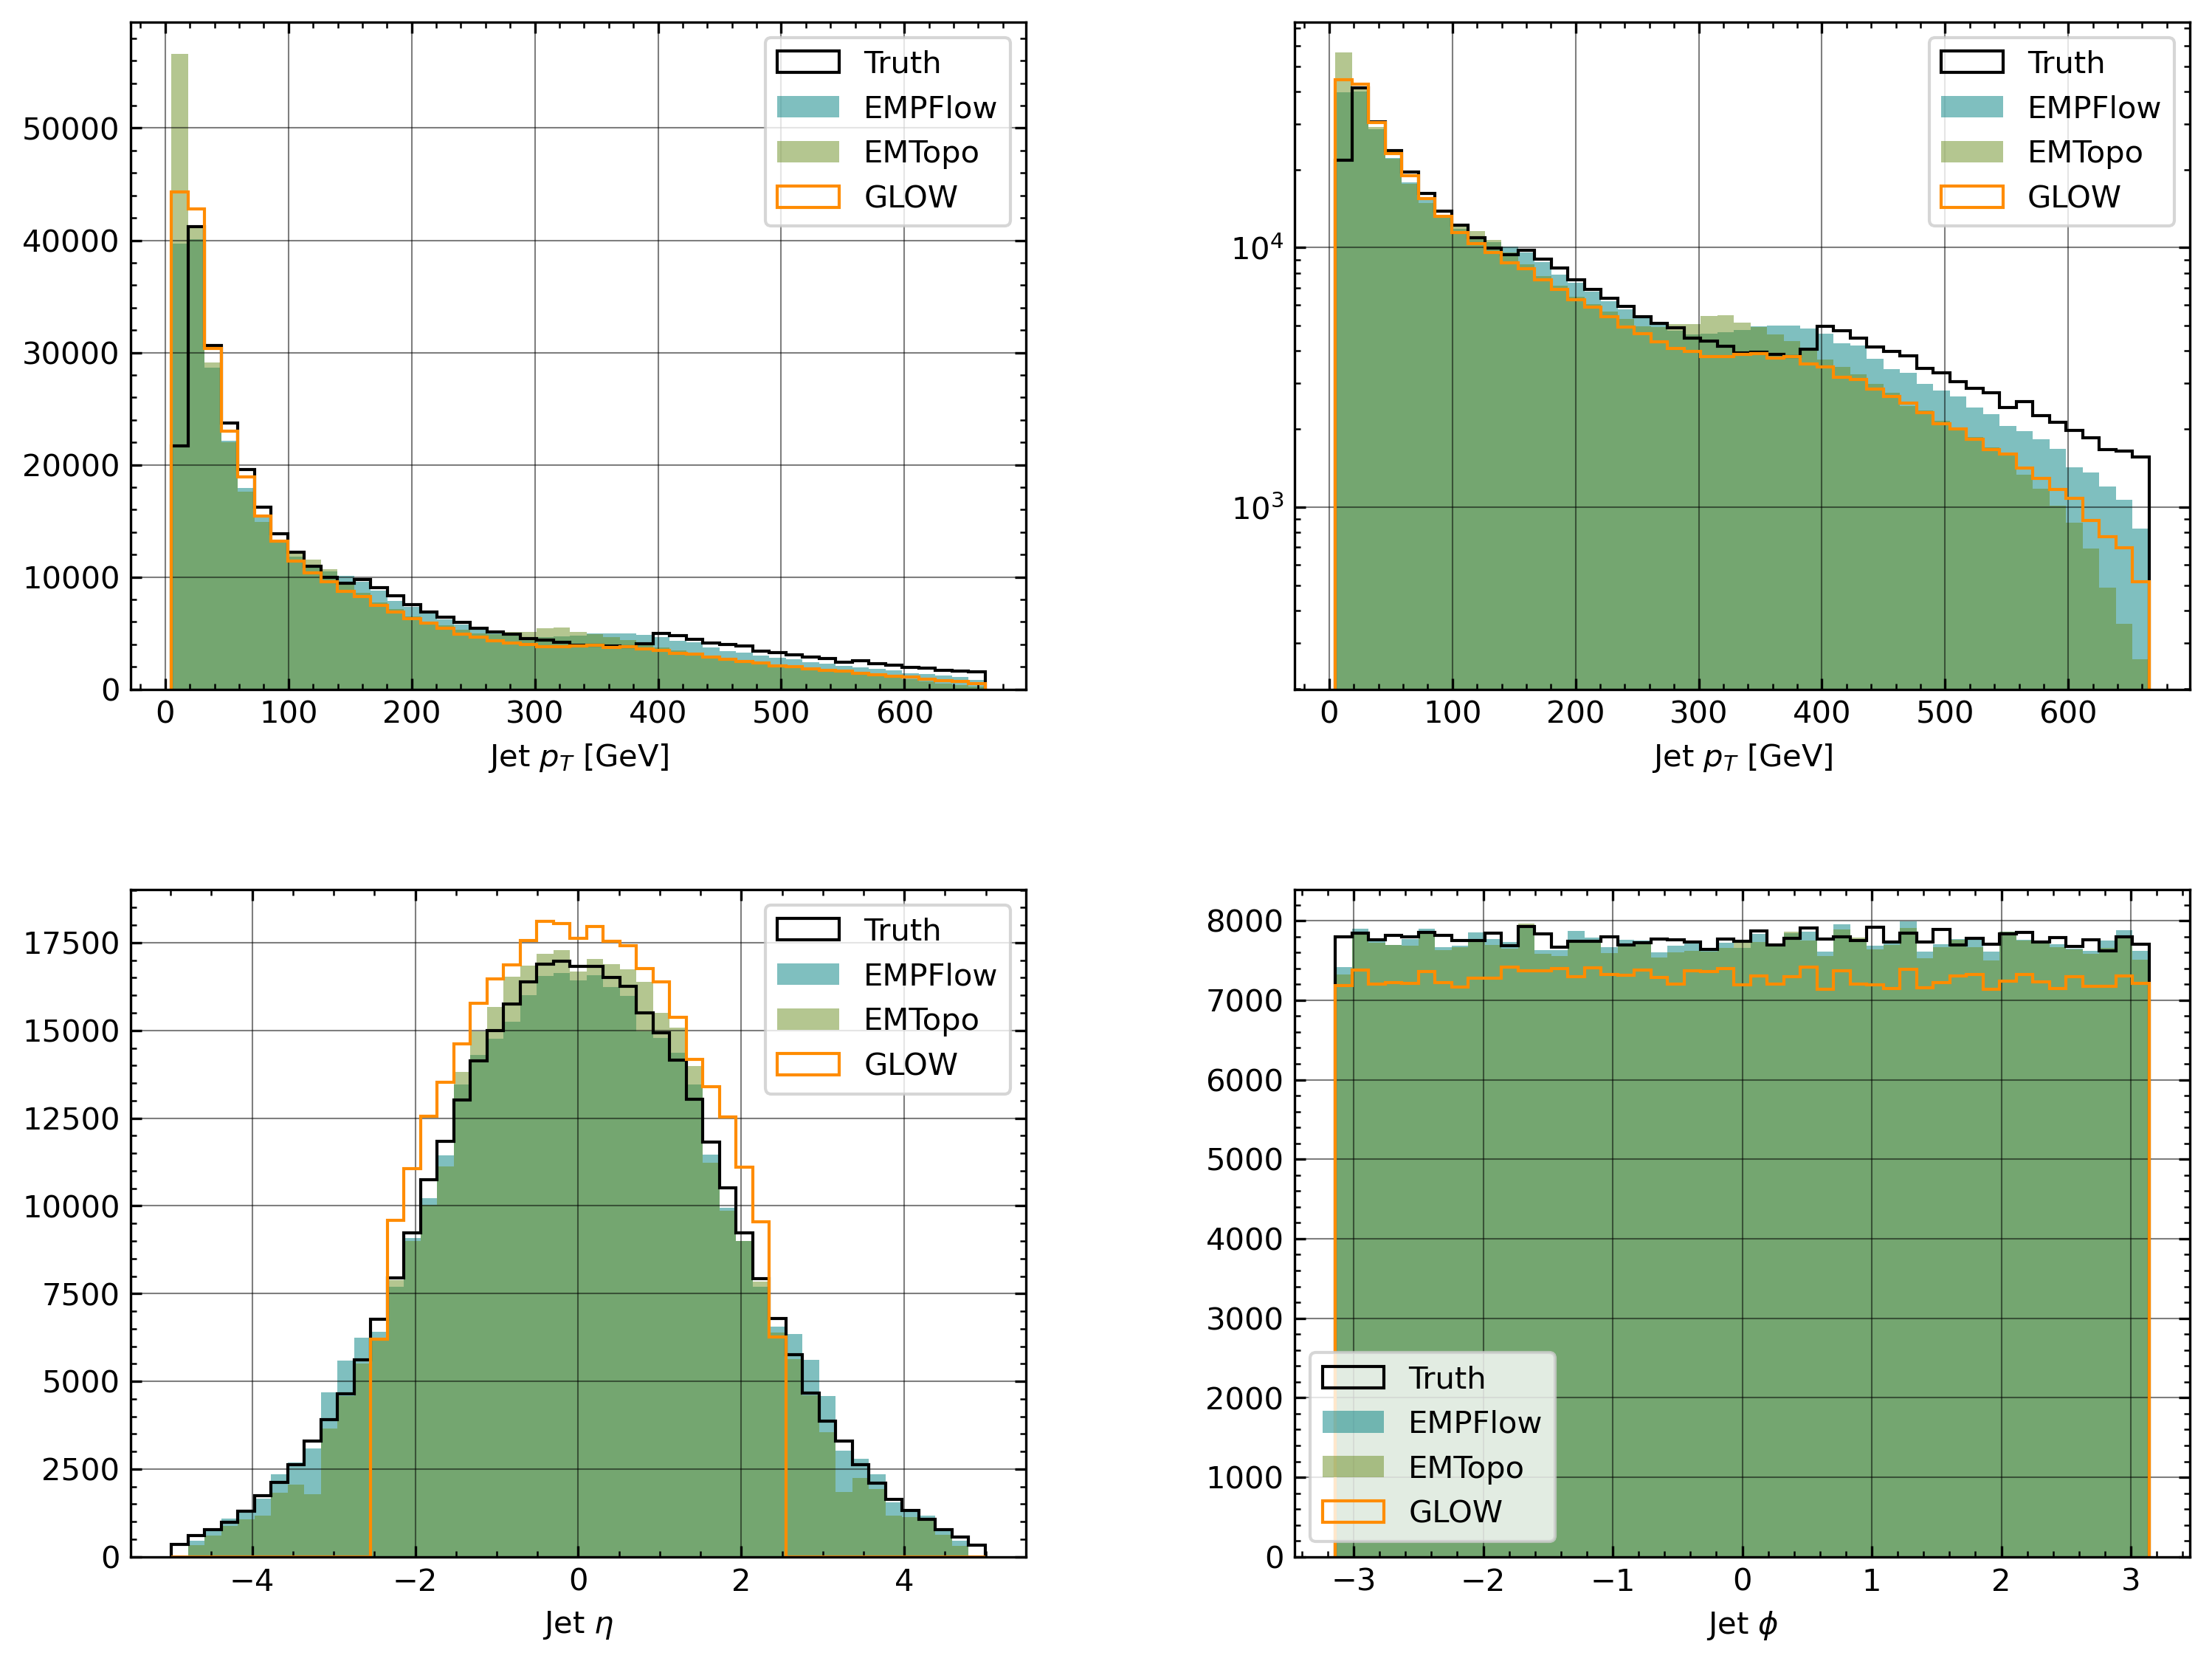

In [40]:
_jet_dict = {
    # 'truth': perf_obj.truth_dict['truth_jets'],
    'truth': perf_obj.truth_dict['AntiKt4TruthJets'],
    'empflow': perf_obj.truth_dict['AntiKt4EMPFlowJets'],
    'emtopo': perf_obj.truth_dict['AntiKt4EMTopoJets'],
    # 'hgpflow': perf_obj.pred_dicts['hgpflow']['jets'],
    # 'proxy': perf_obj.pred_dicts['mpflow']['jets'],
    'mpflow': perf_obj.pred_dicts['mpflow']['jets'],
    # 'topo': perf_obj.truth_dict['topo_jets'],
}

from hgpflow_v2.performance.plot_helper_event import plot_jet_marginals
fig = plot_jet_marginals(_jet_dict, nleading=2, stylesheet=style_sheet)

#### Efficiency and fakerate

In [ ]:
perf_obj.hung_match_particles(flatten=True, return_unmatched=True, dR_threshold=0.5)

ak->np comversion... done


Matching particles...:  36%|███▌      | 3563/10000 [00:18<00:33, 194.64it/s]


KeyboardInterrupt: 

In [ ]:
style_sheet_eff_fr = {
    'LABELS': {
        'hgpflow': 'HGPflow',
        'mpflow': 'GLOW',
    },
    'LINE_STYLES': {
        'hgpflow': '-',
        'mpflow': '--',
    },
    'COLORS': {
        'hgpflow': {
            'neut had': 'mediumseagreen',
            'photon': 'tomato',
        },
        'mpflow': {
            'neut had': 'mediumseagreen',
            'photon': 'tomato',
        }
    }
}

In [ ]:
perf_obj.pred_dicts['mpflow']['matched_mpflow_particles']

({'pt': array([4.17769098, 8.87205601, 5.24744987, ..., 1.7865684 , 1.38359392,
         1.02667964], shape=(721246,)),
  'eta': array([-2.39829731, -2.49024391, -2.42017746, ..., -0.72026986,
         -0.75746125, -0.37137961], shape=(721246,)),
  'phi': array([-3.12842798,  3.05842733,  0.63057226, ..., -0.07076341,
         -0.14816085,  2.30518103], shape=(721246,)),
  'class': array([0, 0, 0, ..., 4, 4, 4], shape=(721246,))},
 {'pt': array([4.12962484, 6.65121889, 5.13707399, ..., 0.74017036, 0.8806935 ,
         1.03342247], shape=(721246,)),
  'eta': array([-2.390625  , -2.49609375, -2.42578125, ..., -0.72949219,
         -0.70605469, -0.36474609], shape=(721246,)),
  'phi': array([-3.12767768,  3.06917071,  0.63023102, ...,  0.01427068,
         -0.182219  ,  2.31466722], shape=(721246,)),
  'class': array([0, 0, 0, ..., 3, 4, 4], shape=(721246,))},
 {'pt': array([1.84156358, 2.04486609, 0.37402895, ..., 0.15066864, 0.08323321,
         0.03872672], shape=(4671716,)),
  'eta': 

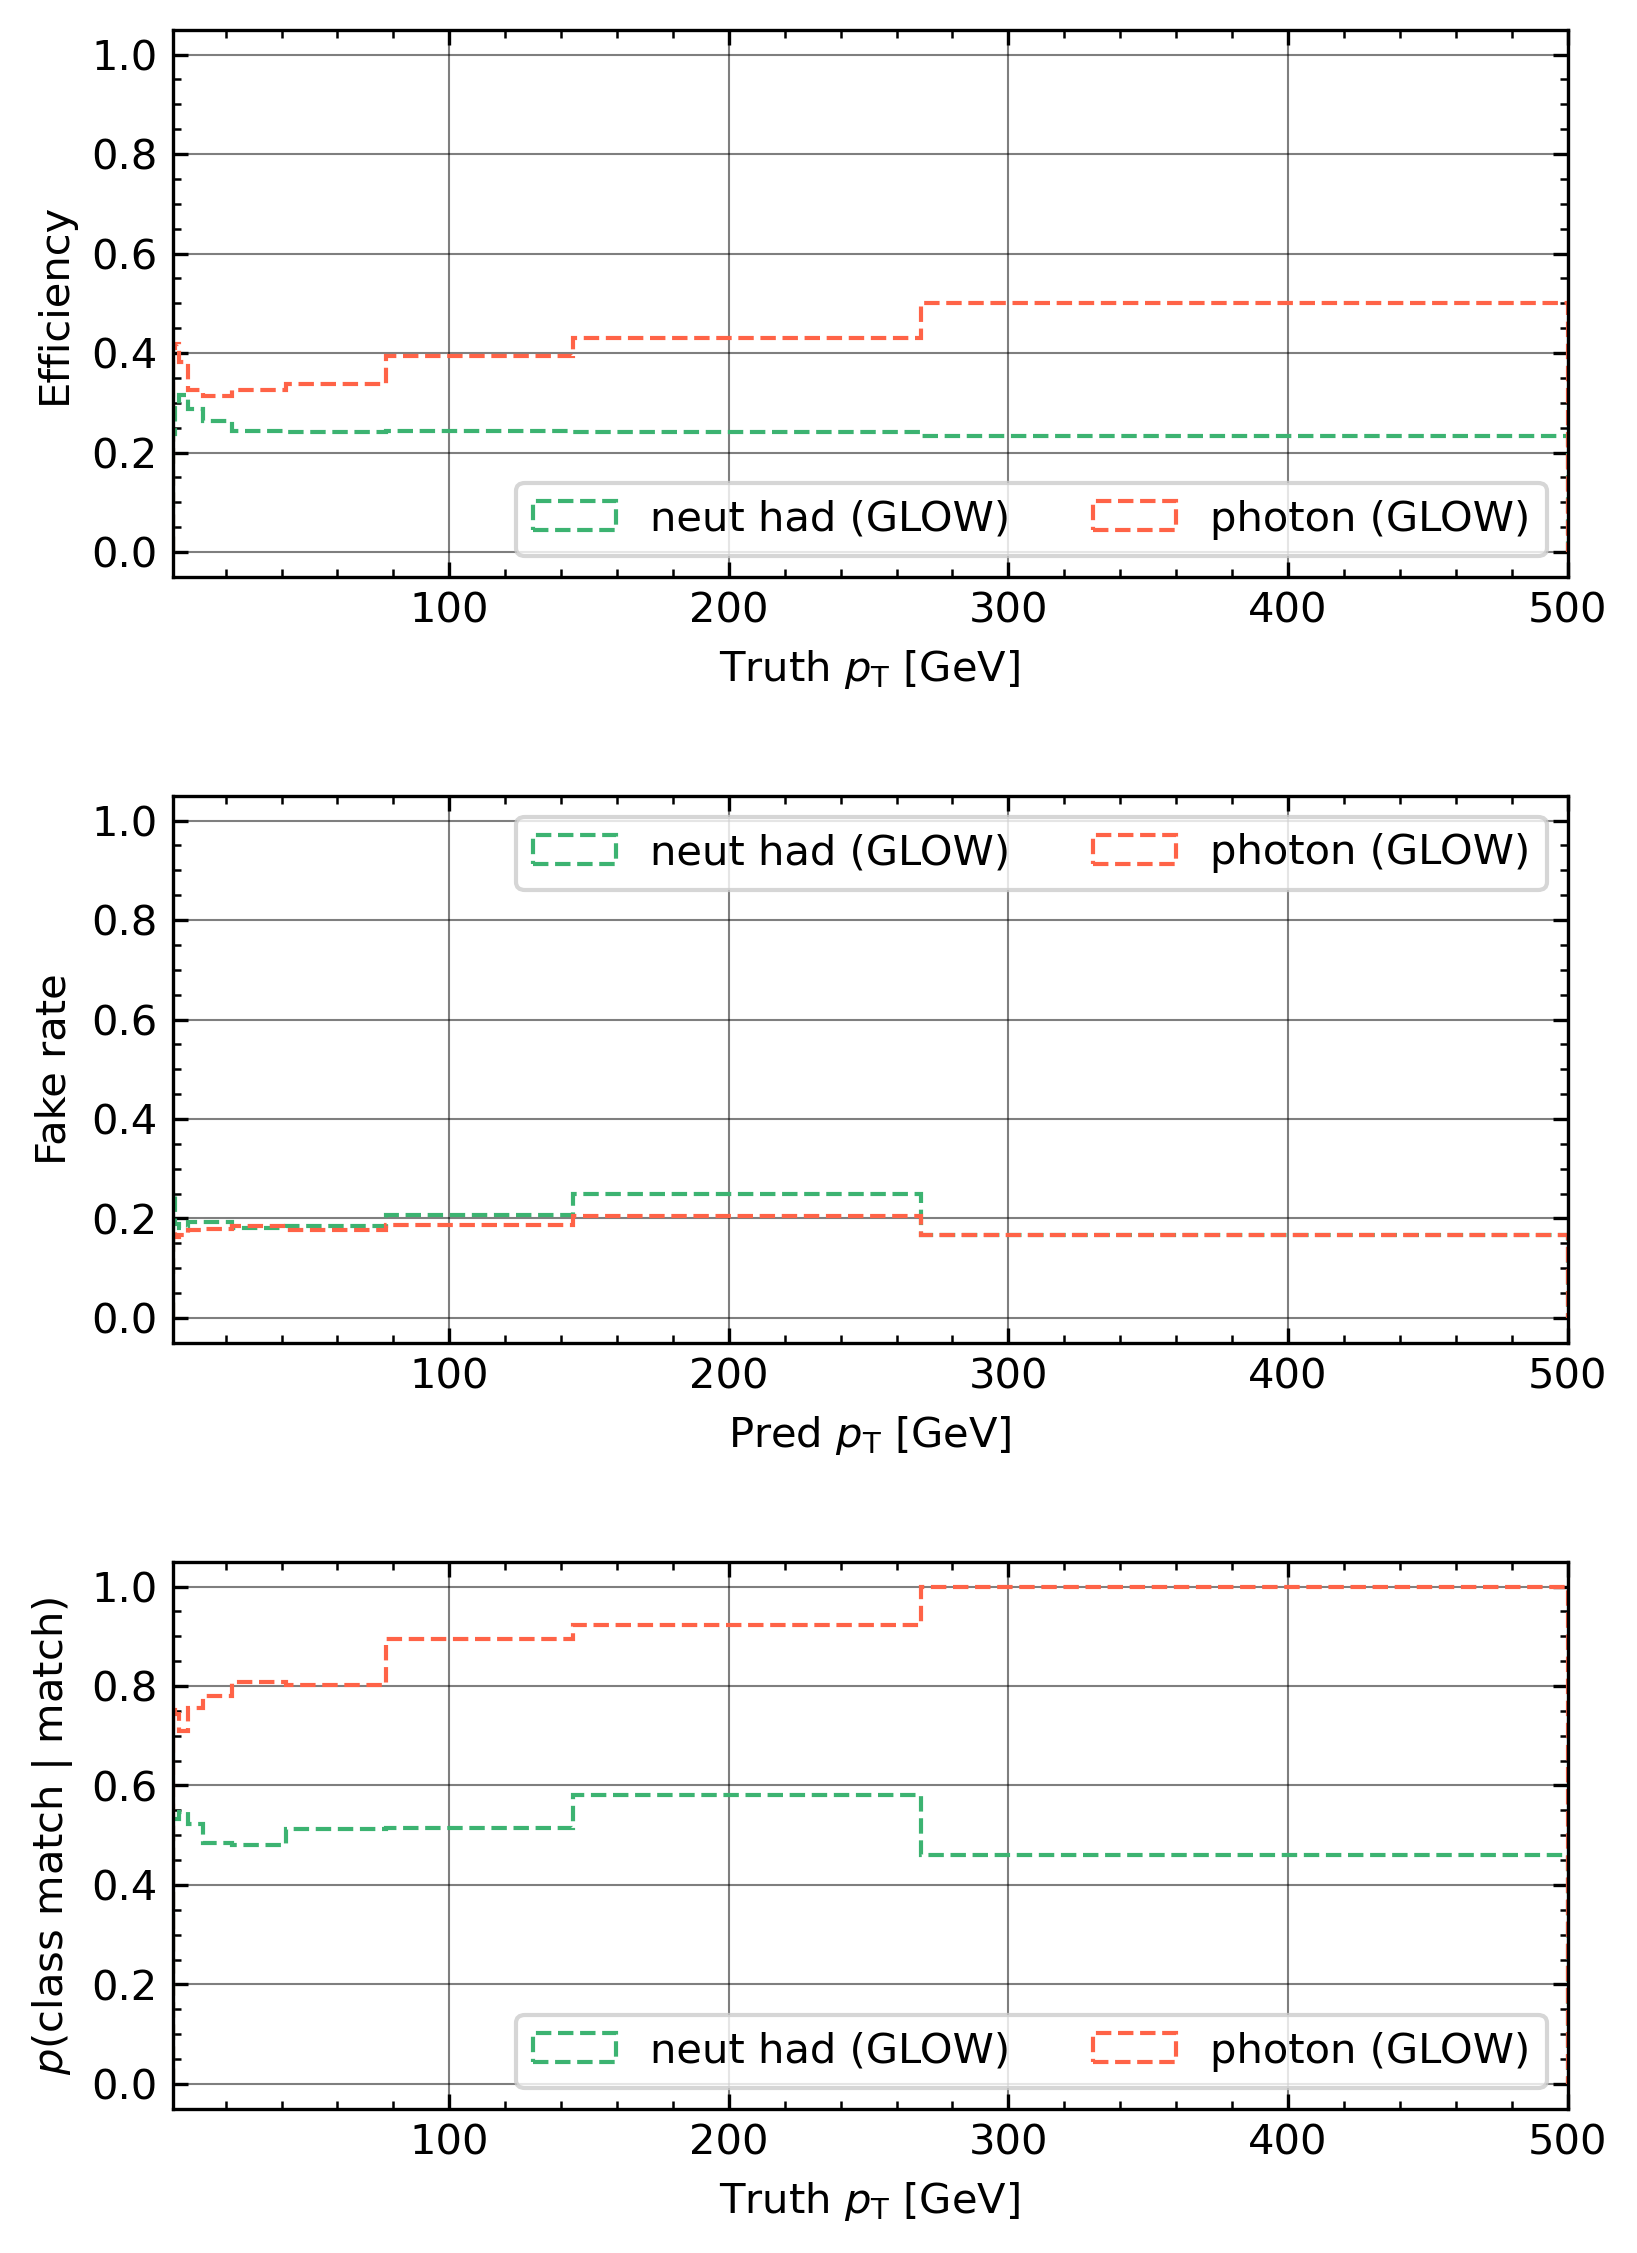

In [ ]:
from hgpflow_v2.performance.plot_helper_particle import plot_eff_fr_purity

eff_fr_purity_input_dict = {
    # 'hgpflow': {
    #     'ref_matched': perf_obj.pred_dicts['hgpflow']['matched_hgpflow_particles'][0],
    #     'comp_matched': perf_obj.pred_dicts['hgpflow']['matched_hgpflow_particles'][1],
    #     'ref_unmatched': perf_obj.pred_dicts['hgpflow']['matched_hgpflow_particles'][2],
    #     'comp_unmatched': perf_obj.pred_dicts['hgpflow']['matched_hgpflow_particles'][3],
    # },
    'mpflow': {
        'ref_matched': perf_obj.pred_dicts['mpflow']['matched_mpflow_particles'][0],
        'comp_matched': perf_obj.pred_dicts['mpflow']['matched_mpflow_particles'][1],
        'ref_unmatched': perf_obj.pred_dicts['mpflow']['matched_mpflow_particles'][2],
        'comp_unmatched': perf_obj.pred_dicts['mpflow']['matched_mpflow_particles'][3],
    }
}

fig = plot_eff_fr_purity(eff_fr_purity_input_dict, stylesheet=style_sheet_eff_fr)
if SAVE_FIG:
    fig.savefig(f'{save_dir}/dijet_eff_fr_purity.png', dpi=300, bbox_inches='tight')

#### Residuals

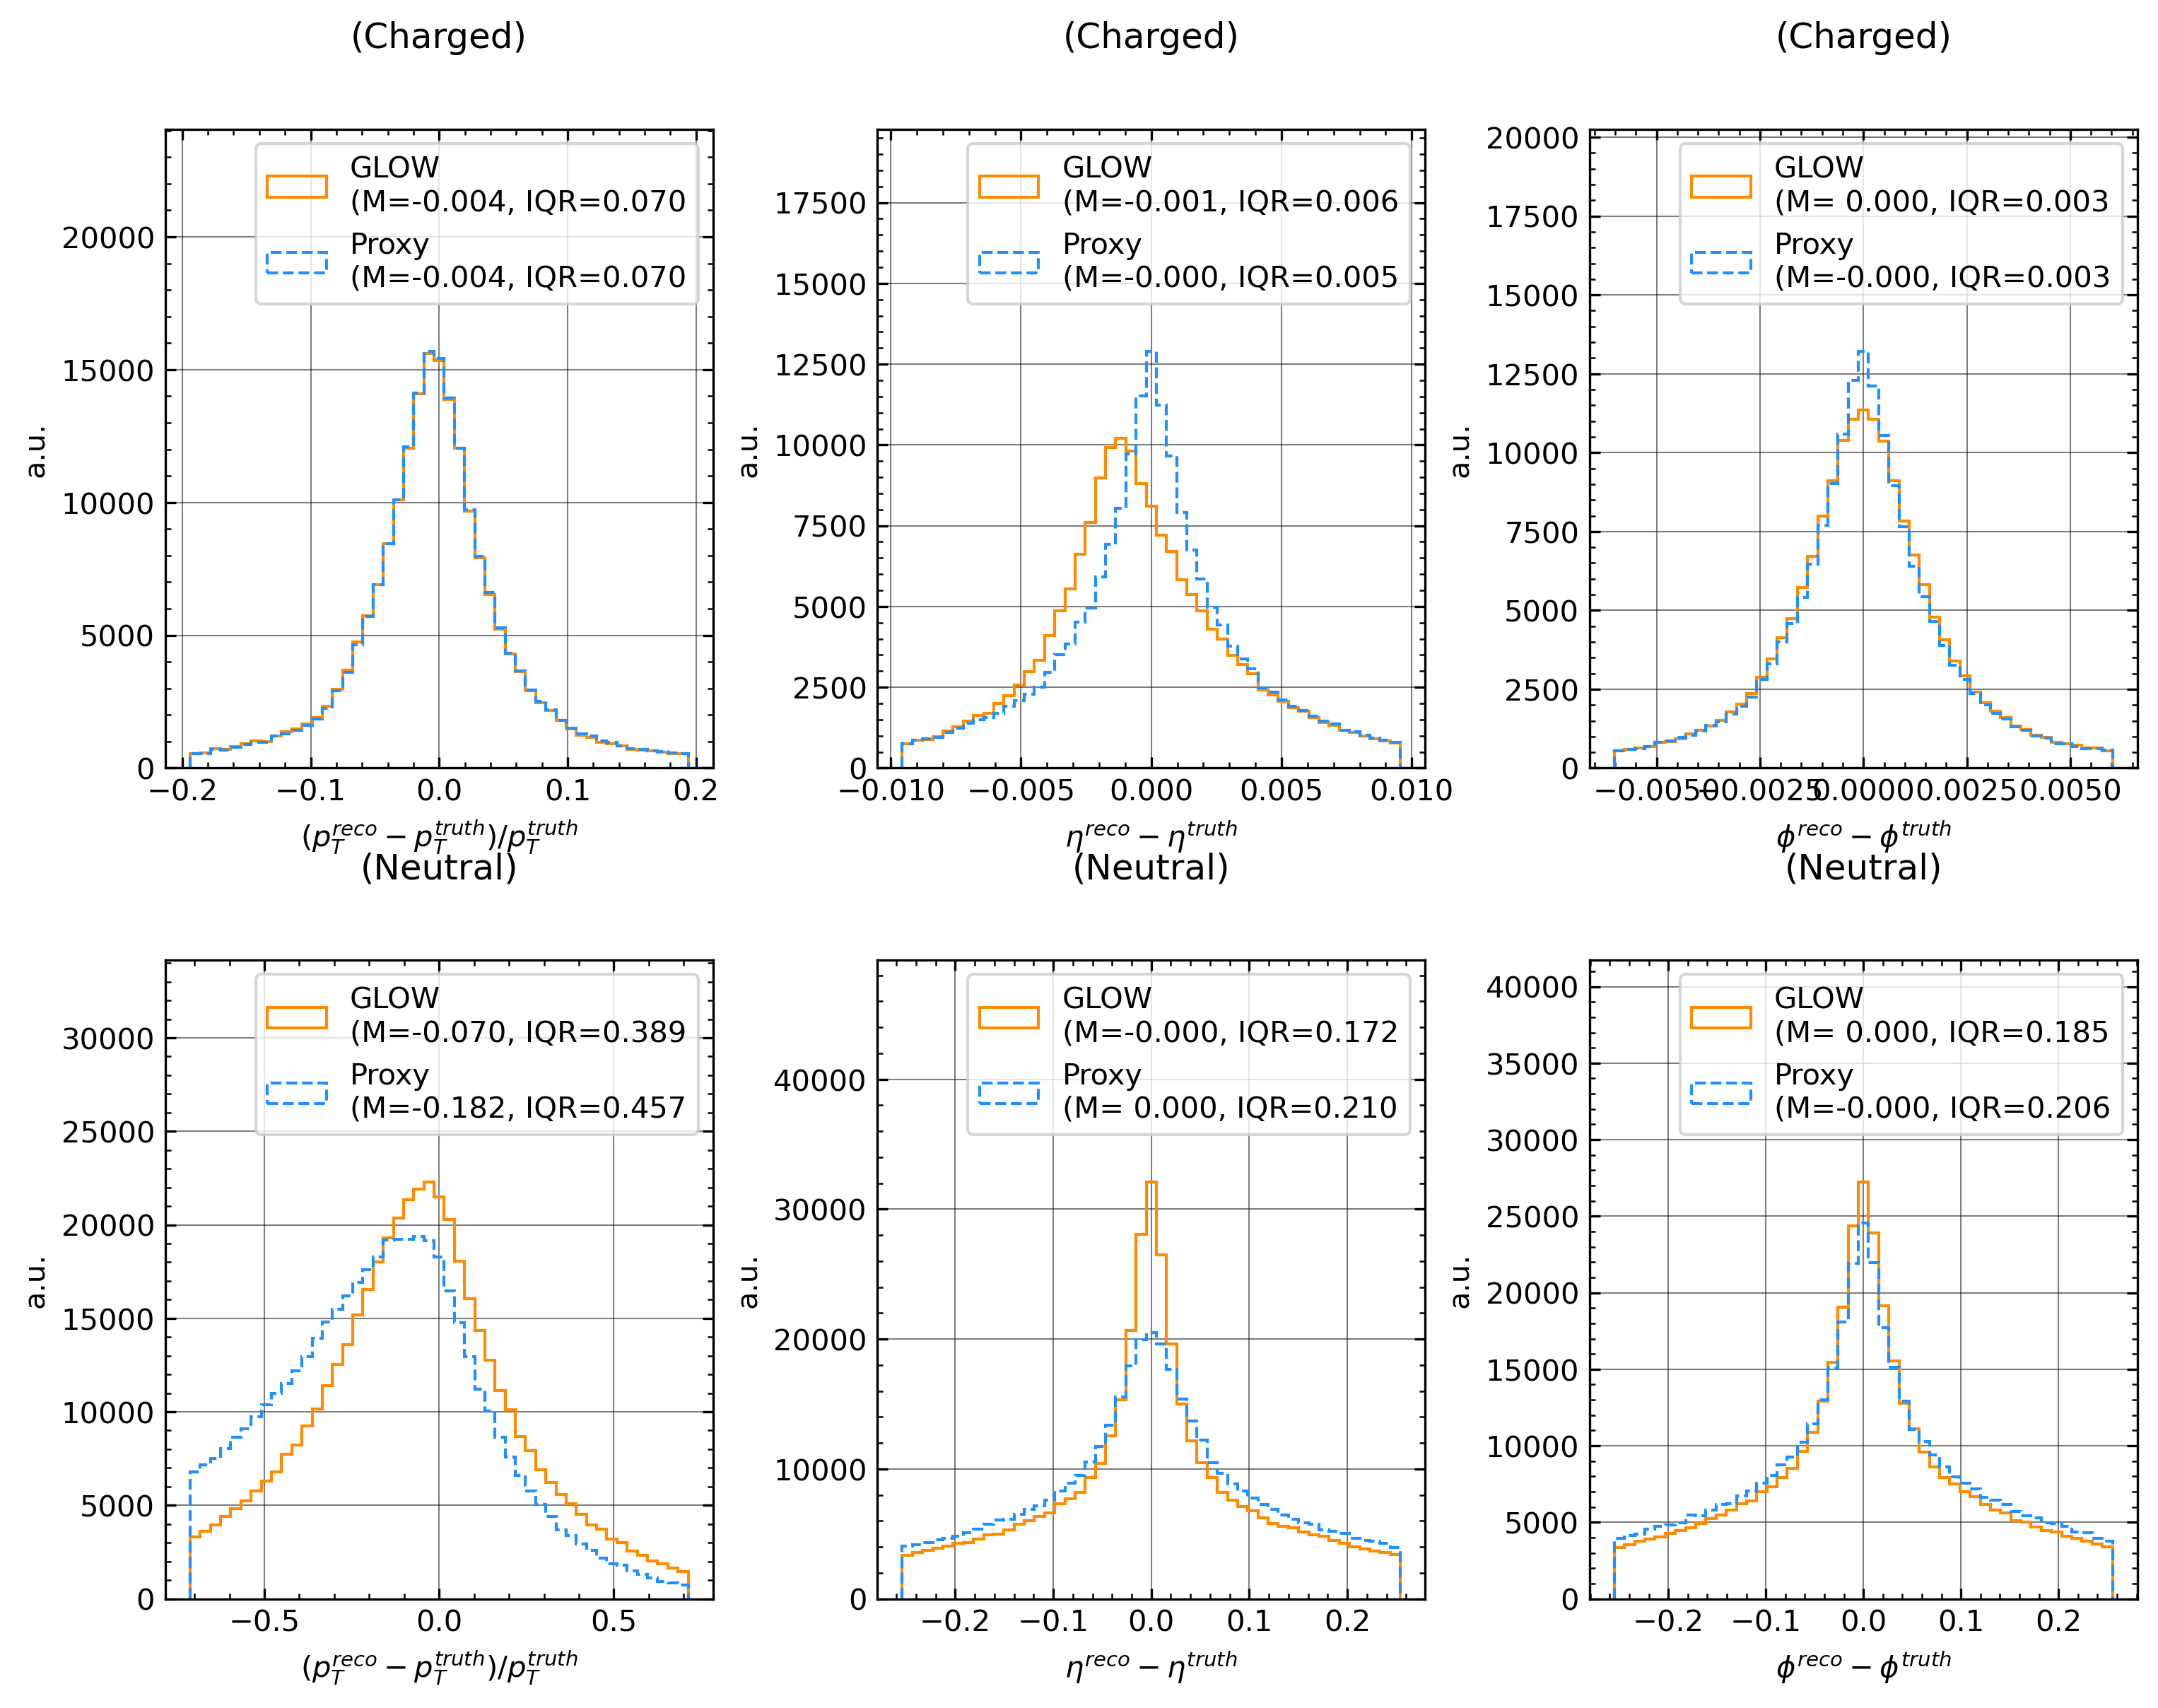

In [ ]:
from hgpflow_v2.performance.plot_helper_particle import plot_residuals

style_sheet_part_res = deepcopy(style_sheet)
style_sheet_part_res['COLORS']['proxy'] = 'dodgerblue'
style_sheet_part_res['LINE_STYLES']['proxy'] = '--'

_dict = {
    'mpflow': perf_obj.pred_dicts['mpflow']['matched_mpflow_particles'],
    # 'hgpflow': perf_obj.pred_dicts['hgpflow']['matched_hgpflow_particles'],
    'proxy': perf_obj.pred_dicts['mpflow']['matched_proxy_particles'],
}

qs = {
    'Charged': {'pt': 90, 'eta': 80, 'phi': 80}, 
    'Neutral': {'pt': 90, 'eta': 80, 'phi': 80}
}
fig = plot_residuals(_dict, pt_relative=True, log_y=False, qs=qs, stylesheet=style_sheet_part_res)
if SAVE_FIG:
    fig.savefig(f'{save_dir}/dijet_particle_residuals.png', dpi=300, bbox_inches='tight')

In [ ]:
from hgpflow_v2.performance.plot_helper_particle import plot_residuals_neutrals

_dict = {
    'mpflow': perf_obj.pred_dicts['mpflow']['matched_mpflow_particles'],
    # 'hgpflow': perf_obj.pred_dicts['hgpflow']['matched_hgpflow_particles'],
    'proxy': perf_obj.pred_dicts['mpflow']['matched_proxy_particles'],
}

qs = {
    'Neutral hadron': {'pt': 98, 'eta': 75, 'phi': 75}, 
    'Photon': {'pt': 99, 'eta': 90, 'phi': 90}
}
figs = plot_residuals_neutrals(_dict, pt_relative=True, log_y=False, qs=qs, stylesheet=style_sheet_part_res, separate_figures=False)
if SAVE_FIG:
    figs[0].savefig(f'{save_dir}/dijet_particle_residuals_neutralhad_pt.png', dpi=300, bbox_inches='tight')
    figs[1].savefig(f'{save_dir}/dijet_particle_residuals_neutralhad_eta.png', dpi=300, bbox_inches='tight')
    figs[2].savefig(f'{save_dir}/dijet_particle_residuals_neutralhad_phi.png', dpi=300, bbox_inches='tight')
    figs[3].savefig(f'{save_dir}/dijet_particle_residuals_photon_pt.png', dpi=300, bbox_inches='tight')
    figs[4].savefig(f'{save_dir}/dijet_particle_residuals_photon_eta.png', dpi=300, bbox_inches='tight')
    figs[5].savefig(f'{save_dir}/dijet_particle_residuals_photon_phi.png', dpi=300, bbox_inches='tight')